# Train a model

Choose the model with **`MODEL`**; everything else (data, day-ahead rule, scoring) is the shared benchmark from `forecast/` (see `TASK0_README.md`).

| `MODEL` | What it is | `MODEL_PARAMS` |
|---|---|---|
| `"gbm"` | Gradient boosting on the standard features, one global model for all households (the reference setup) | any `HistGradientBoostingRegressor` argument |
| `"sarimax"` | SARIMAX on the **daily portfolio** consumption per household, with yesterday's heating degrees and a weekend flag as regressors; distributed to households and 15 min by scaling each household's reading from yesterday with the predicted change | `order`, `seasonal_order` (default: chosen by AIC on the training data) |

**Why SARIMAX at portfolio level?** Single households' 15-min series are noisy, there are 375 of them, and the seasonal periods (96 per day, 672 per week) make 15-min SARIMA slow and unstable. The daily portfolio series is smooth and strongly autocorrelated, which is exactly where ARIMA works well, and it gives prediction intervals.

To add a model: write a function `(df, config, **params) -> predictions` in `forecast/models.py` and add it to `MODELS`.

In [1]:
from forecast import Config, evaluate, features
from forecast.models import train_and_predict

MODEL = "sarimax"          # "gbm" | "sarimax"
MODEL_PARAMS = {}          # e.g. {"order": (2, 1, 2), "seasonal_order": (1, 0, 0, 7)} to skip the AIC search
config = Config(weather_resampling="step")

NAME = f"{MODEL}_{config.weather_resampling}"
AUTHOR = "pengxuanHuang"
DESCRIPTION = {"gbm": "Gradient boosting, standard features",
               "sarimax": "SARIMAX on daily portfolio (HDD of D-1, weekend), distributed via yesterday's profile"}[MODEL]

## 1. Features (shared, respects the day-ahead rule)

In [ ]:
df, household_ids = features.build_features(config)
print(f"{len(household_ids)} households loaded")

## 2. Train and predict every test row

In [3]:
predictions = train_and_predict(MODEL, df, config, **MODEL_PARAMS)
info = predictions.attrs["info"]
{k: v for k, v in info.items() if k not in ("summary", "daily")}

{'order': (2, 1, 2),
 'seasonal_order': (1, 0, 0, 7),
 'train_days': '2020-10-01 .. 2023-02-28',
 'coefficients': {'hdd_1d': 0.3965,
  'is_weekend': 1.7459,
  'ar.L1': -0.0989,
  'ar.L2': 0.6266,
  'ma.L1': -0.0078,
  'ma.L2': -0.8038,
  'ar.S.L7': 0.0911,
  'sigma2': 9.3129}}

## 3. Submit to the shared leaderboard

In [4]:
evaluate.submit(predictions, NAME, AUTHOR, DESCRIPTION, config=config.to_dict(),
                params={"model": MODEL, **MODEL_PARAMS, **{k: info[k] for k in ("order", "seasonal_order") if k in info}})

Submitted 'sarimax_step'. Portfolio nMAE: 13.12 % per 15 min, 7.40 % per day


,MAE,RMSE,nMAE,bias
portfolio_15min,13.172,18.718,13.123,0.338
portfolio_day,712.287,1054.626,7.400,0.298
household_15min,0.195,0.371,69.387,0.338
household_day,5.423,9.162,20.137,0.298


In [5]:
evaluate.leaderboard()

,author,date,description,portfolio_15min_nMAE,portfolio_15min_bias,portfolio_day_nMAE,portfolio_day_bias,household_15min_nMAE,household_15min_bias,household_day_nMAE,household_day_bias
name,,,,,,,,,,,
gbm_step,pengxuanHuang,2026-10-06 18:05,"Gradient boosting, standard features",11.64,0.86,7.79,0.86,62.47,0.86,21.44,0.86
gbm_interpolate,pengxuanHuang,2026-10-06 16:53,"HistGradientBoosting, standard features, weath...",11.68,0.82,7.84,0.82,62.50,0.82,21.53,0.82
sarimax_step,pengxuanHuang,2026-10-06 18:07,"SARIMAX on daily portfolio (HDD of D-1, weeken...",13.12,0.34,7.40,0.30,69.39,0.34,20.14,0.30
naive_lag_1d,reference,2026-10-06 17:53,"Same 15 min yesterday (fallback: 7 days ago, h...",13.41,0.28,7.90,0.20,69.23,0.28,20.34,0.20
linear_example,your-name,2026-10-06 17:35,Linear regression on numeric standard features...,13.43,2.23,8.74,2.22,65.71,2.23,23.42,2.22
naive_lag_7d,reference,2026-10-06 17:53,"Same 15 min one week ago (fallback: yesterday,...",20.45,0.60,16.92,0.52,73.03,0.60,29.23,0.52


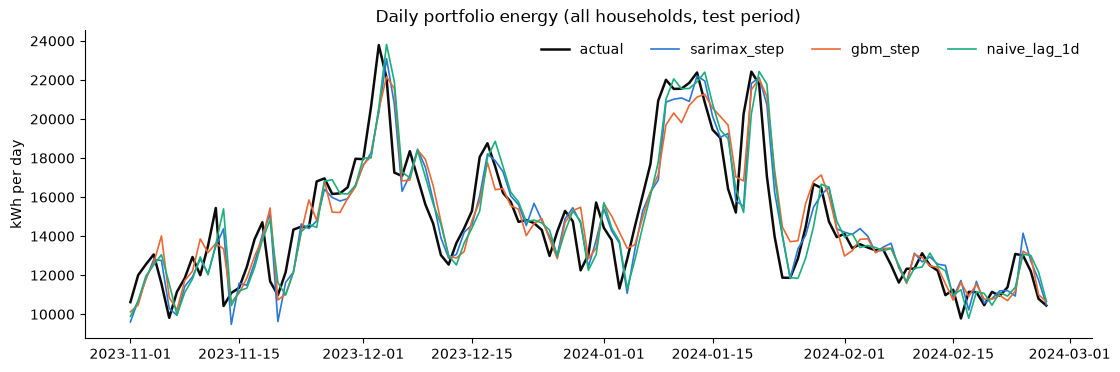

In [6]:
evaluate.plot_daily([NAME, "gbm_step", "naive_lag_1d"], start="2023-11-01")

## 4. SARIMAX only: model details and prediction intervals (Level 3)

The coefficients show how the daily consumption per household reacts to yesterday's heating degrees and to weekends. The intervals show how certain each daily forecast is; for a well-calibrated model about 80 % / 95 % of the actual days fall inside.

In [7]:
if MODEL == "sarimax":
    print(info["summary"])

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  881
Model:             SARIMAX(2, 1, 2)x(1, 0, [], 7)   Log Likelihood               -2230.651
Date:                            Tue, 06 Oct 2026   AIC                           4477.302
Time:                                    18:07:18   BIC                           4515.541
Sample:                                10-01-2020   HQIC                          4491.925
                                     - 02-28-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
hdd_1d         0.3965      0.079      5.016      0.000       0.242       0.551
is_weekend     1.7459      0.240   

80 % interval contains the actual value on 86.0% of test days
95 % interval contains the actual value on 93.1% of test days


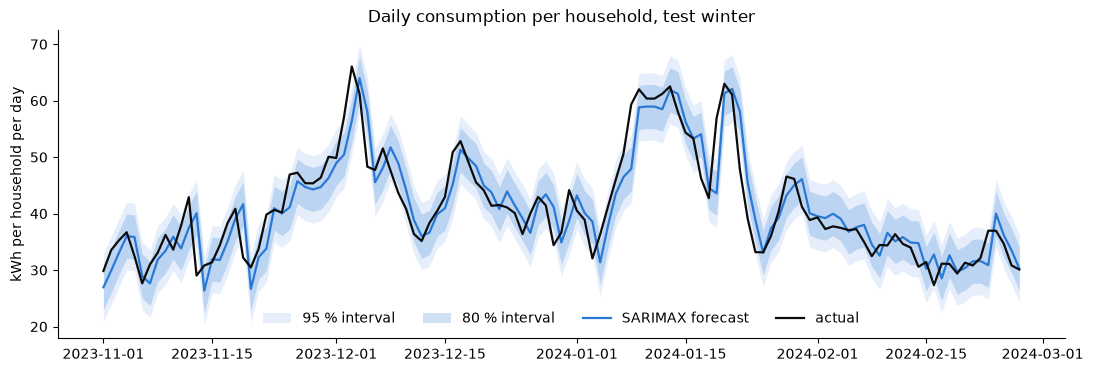

In [8]:
if MODEL == "sarimax":
    import matplotlib.pyplot as plt

    daily = info["daily"].iloc[:-1]  # the last test day only has 4 readings
    for level in (80, 95):
        inside = daily["actual"].between(daily[f"lower_{level}"], daily[f"upper_{level}"])
        print(f"{level} % interval contains the actual value on {inside.mean():.1%} of test days")

    winter = daily.loc["2023-11-01":]
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.fill_between(winter.index, winter["lower_95"], winter["upper_95"], color="#2a78d6", alpha=0.12, linewidth=0, label="95 % interval")
    ax.fill_between(winter.index, winter["lower_80"], winter["upper_80"], color="#2a78d6", alpha=0.22, linewidth=0, label="80 % interval")
    ax.plot(winter.index, winter["forecast"], color="#2a78d6", linewidth=1.6, label="SARIMAX forecast")
    ax.plot(winter.index, winter["actual"], color="#0b0b0b", linewidth=1.6, label="actual")
    ax.set(title="Daily consumption per household, test winter", ylabel="kWh per household per day")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, ncol=4)
    plt.show()

## 5. Optional: ensemble of two submissions

Averages two saved submissions (their `.npy` files must exist locally). The 50/50 weight is fixed on purpose: tuning it on the test year would leak test information into the model.

In [9]:
A, B = "gbm_step", "sarimax_step"
try:
    a, b = evaluate.load_predictions(A), evaluate.load_predictions(B)
    ensemble = a[["Household_ID", "Timestamp"]].assign(prediction=0.5 * a["prediction"] + 0.5 * b["prediction"])
    evaluate.submit(ensemble, f"ensemble_{A}_{B}", AUTHOR, f"50/50 average of {A} and {B}")
except FileNotFoundError as missing:
    print(f"Run both models first: {missing}")

Submitted 'ensemble_gbm_step_sarimax_step'. Portfolio nMAE: 11.77 % per 15 min, 7.38 % per day
